# Experiment No 6

**Aim:** To build K-Nearest Neighbor (KNN) and Support Vector Machine (SVM) classification models on the Spambase dataset and evaluate their performance using appropriate metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

spambase = fetch_ucirepo(id=94)
df = pd.concat([spambase.data.features, spambase.data.targets], axis=1)
display(df.head(3))

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1


### Preprocessing

In [2]:
X_data = df.drop(columns=['Class'])
y_data = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### KNN – Optimal K Selection

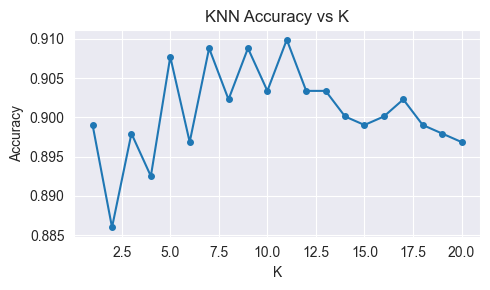

In [3]:
k_range = range(1, 21)
k_scores = [KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
             .score(X_test_scaled, y_test) for k in k_range]

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(k_range, k_scores, marker='o', markersize=4)
ax.set_xlabel('K'); ax.set_ylabel('Accuracy')
ax.set_title('KNN Accuracy vs K')
plt.tight_layout(); plt.show()

best_k = k_range[np.argmax(k_scores)]

### KNN – Train & Evaluate

In [4]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

metrics_knn = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_knn)],
    'Recall':    [recall_score(y_test, y_pred_knn)],
    'F1-Score':  [f1_score(y_test, y_pred_knn)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_knn)]
}).round(4)
display(metrics_knn)
print(classification_report(y_test, y_pred_knn, target_names=['Not Spam', 'Spam']))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.9099,0.9,0.8678,0.8836,0.9622


              precision    recall  f1-score   support

    Not Spam       0.92      0.94      0.93       558
        Spam       0.90      0.87      0.88       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921



### Confusion Matrix & ROC Curve – KNN

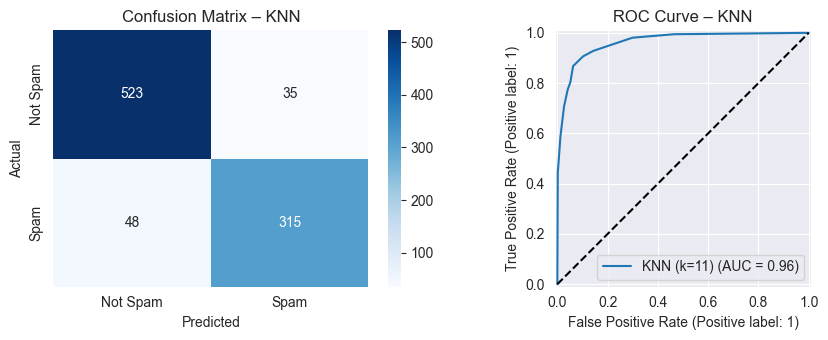

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix – KNN')

RocCurveDisplay.from_predictions(y_test, y_prob_knn, ax=axes[1], name=f'KNN (k={best_k})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve – KNN')

plt.tight_layout(); plt.show()

### SVM – Train & Evaluate

In [6]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

metrics_svm = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_svm)],
    'Recall':    [recall_score(y_test, y_pred_svm)],
    'F1-Score':  [f1_score(y_test, y_pred_svm)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_svm)]
}).round(4)
display(metrics_svm)
print(classification_report(y_test, y_pred_svm, target_names=['Not Spam', 'Spam']))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.9273,0.9277,0.8843,0.9055,0.9667


              precision    recall  f1-score   support

    Not Spam       0.93      0.96      0.94       558
        Spam       0.93      0.88      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



### Confusion Matrix & ROC Curve – SVM

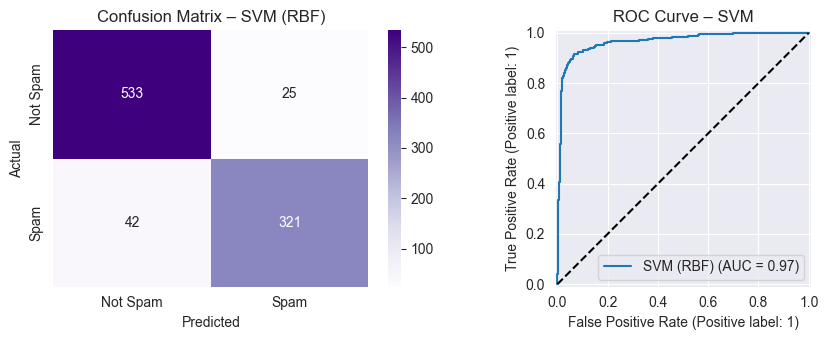

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d',
            cmap='Purples', ax=axes[0],
            xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix – SVM (RBF)')

RocCurveDisplay.from_predictions(y_test, y_prob_svm, ax=axes[1], name='SVM (RBF)')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve – SVM')

plt.tight_layout(); plt.show()

## Conclusion

SVM with an RBF kernel outperforms KNN on Spambase by finding an optimal hyperplane in a high-dimensional feature space, making it more robust to noisy and correlated features. KNN is sensitive to the choice of K and suffers in high dimensions due to the curse of dimensionality.